# Statistiques initiales sur le corpus

### Nombre auteurs uniques par genre

In [ ]:
import pandas as pd

# Percorso del file
file_path = "Metadata_corpus.csv"  # <-- modifica qui

# Caricamento dati
df = pd.read_csv(file_path, sep=';')

# Pulizia base
df = df.dropna(subset=['Author', 'Author gender'])

# Conteggio autori unici per genere
counts = df.groupby('Author gender')['Author'].nunique()

# Output
print("Nombre auteurs uniques par genre:")
display(counts)

Nombre auteurs uniques par genre:


Author gender
female    42
male      34
Name: Author, dtype: int64

### Répartition des livres par année

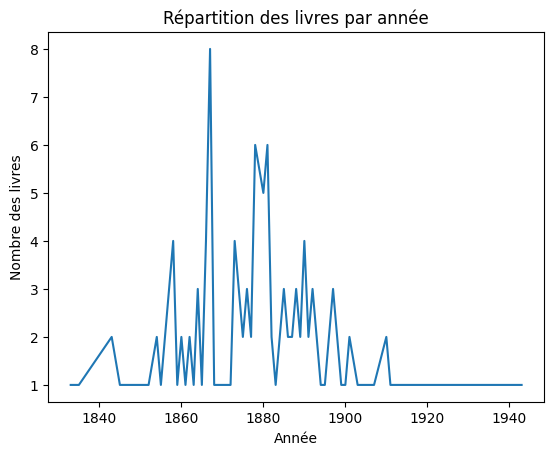

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Metadata_corpus.csv"  # <-- modifica qui

# Caricamento dati
df = pd.read_csv(file_path, sep=';')

# Pulizia colonna Year
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])

# Conteggio romanzi per anno
books_per_year = df['Year'].value_counts().sort_index()

# Plot
plt.figure()
plt.plot(books_per_year.index, books_per_year.values)
plt.xlabel("Année")
plt.ylabel("Nombre des livres")
plt.title("Répartition des livres par année")
plt.show()

### Tendance des romans par genre d'auteur

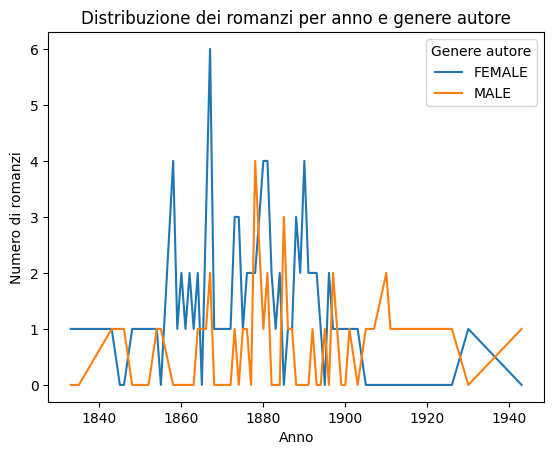

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Metadata_corpus.csv"  # <-- modifica qui

# Caricamento
df = pd.read_csv(file_path, sep=';')

# Pulizia
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Author'] = df['Author'].astype(str).str.strip()
df['Author gender'] = df['Author gender'].astype(str).str.strip().str.upper()

df = df.dropna(subset=['Year', 'Author gender'])

# Conteggio romanzi per anno e genere
counts = (
    df.groupby(['Year', 'Author gender'])
      .size()
      .unstack(fill_value=0)   # colonne = generi
      .sort_index()
)

# Plot
plt.figure()
for gender in counts.columns:
    plt.plot(counts.index, counts[gender], label=gender)

plt.xlabel("Anno")
plt.ylabel("Numero di romanzi")
plt.title("Distribuzione dei romanzi per anno e genere autore")
plt.legend(title="Genere autore")
plt.show()

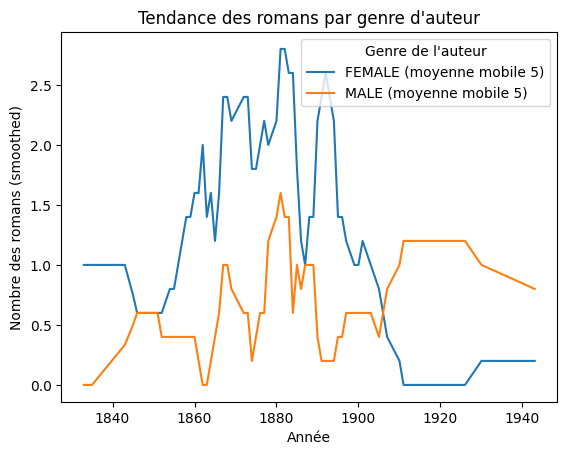

In [17]:
window = 5  # anni

smoothed = counts.rolling(window=window, min_periods=1).mean()

plt.figure()
for gender in smoothed.columns:
    plt.plot(smoothed.index, smoothed[gender], label=f"{gender} (moyenne mobile {window})")

plt.xlabel("Année")
plt.ylabel("Nombre des romans (smoothed)")
plt.title("Tendance des romans par genre d'auteur")
plt.legend(title="Genre de l'auteur")
plt.show()